# Credit Card Fraud — picking a threshold, not a model

A classic operations problem: ~284k card transactions over two days,
~492 of which are fraudulent (about 1 in 580). The job is to flag the
fraud without burying the fraud team in false alarms.

The notebook is laid out as a short paper — **Introduction**, **Data**,
**Methods**, **Results**, **Conclusion** — but the story inside is
that **the model isn't the lever; the threshold is**. Every plot is
followed by a short note covering what to look at, what it means,
and what it indicates next.

## 1. Introduction

*The problem, the cost asymmetry, and what this notebook actually
delivers.*

Every missed fraud is a direct loss to the bank. Every false alarm is
either customer friction (legitimate transactions getting blocked at
the till) or wasted analyst time. The two costs aren't equal, and they
aren't fixed — they depend on the bank's policy.

So the deliverable is not a model. It is a **model plus a defensible
operating threshold** on the model's score, where the precision/recall
tradeoff matches what operations is willing to pay for. The whole arc
of this notebook is to show that on this dataset, the choice of
threshold matters more than the choice of model — and to land on one
defensible threshold for each candidate.

## 2. Data

*Where the dataset comes from, how rare fraud actually is, and which
features show visible signal — leading to the modelling hypothesis in
§2.3.*

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import data
import models
import plots

plots.apply_style()

X_train, y_train, X_val, y_val, X_test, y_test = data.load(seed=0)
print(f"train {X_train.shape} | val {X_val.shape} | test {X_test.shape}")
print(f"positives — train {y_train.sum()}, val {y_val.sum()}, test {y_test.sum()}")

train (182276, 29) | val (45569, 29) | test (56962, 29)
positives — train 315, val 79, test 98


ULB credit-card fraud dataset — 284,807 transactions over two
days in September 2013. Features V1..V28 are PCA components from the
original ULB paper (already roughly standardised); `Amount` is raw and
gets standard-scaled by the loader. Pulled from OpenML so the download
doesn't need a Kaggle account. Stratified 64/16/20 split.

### 2.1 How rare is fraud?

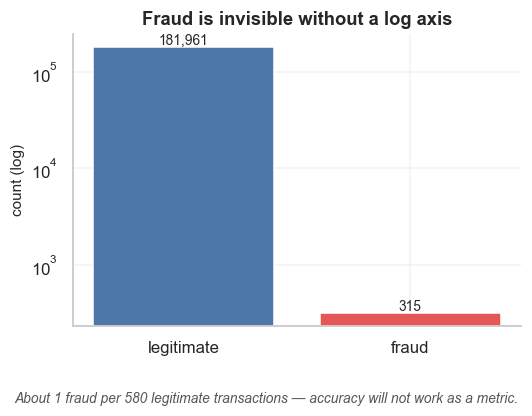

In [2]:
fig, ax = plt.subplots(figsize=(5, 3.5))
plots.class_balance(y_train, ax=ax)
ax.set_title("Fraud is invisible without a log axis")
plots.caption(fig, "About 1 fraud per 580 legitimate transactions — accuracy will not work as a metric.")
plt.tight_layout()
plt.show()

**What it shows.** Log-scaled bar of class counts: ~315 fraud vs ~181,961 legitimate transactions in the training split.

**What the numbers say.** Across the 182,276 / 45,569 / 56,962 train/val/test split, positive rates are 0.173% / 0.173% / 0.172% — same imbalance everywhere by stratification. Test has only **98 actual frauds**, so a single TP move shifts measured recall by **1.02 percentage points**. F1 differences below ~0.02 are within sampling noise.

**Practical consequence.** Predicting "legit" everywhere scores 99.83% accuracy, 0% recall, undefined precision — the trivial baseline. From here on the notebook lives in PR / F1 / PR-AUC space, and the §4.6 ledger reports per-model F1 with the operating point baked in.


### 2.2 Is there visible signal in any feature?

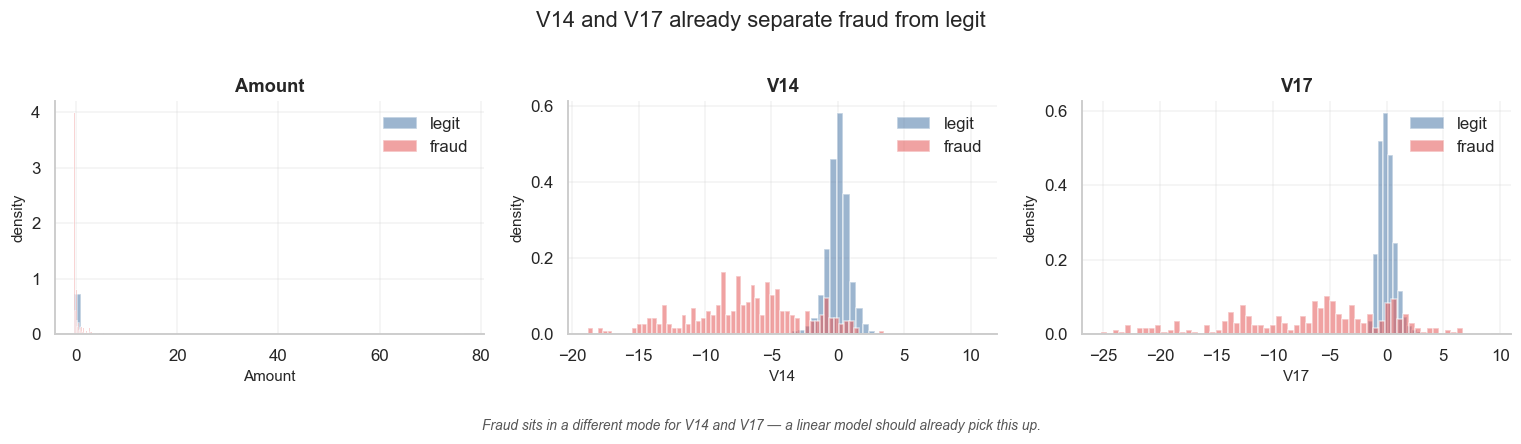

In [3]:
df = pd.DataFrame(np.c_[X_train, y_train], columns=data.FEATURE_NAMES + ["y"])
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
plots.feature_distributions(df, ["Amount", "V14", "V17"], ax_row=axes)
fig.suptitle("V14 and V17 already separate fraud from legit", y=1.02)
plots.caption(fig, "Fraud sits in a different mode for V14 and V17 — a linear model should already pick this up.")
plt.tight_layout()
plt.show()

**What it shows.** Histogram overlays of `V14`, `V17`, `Amount` for fraud (red) vs legit (blue).

**What the numbers say.** V14 and V17 each separate the two distributions with **near-complete tail dominance** — fraud concentrates in the V14 < -3 / V17 < -3 left tails, while legitimate transactions cluster around 0 with light tails. So a single linear cut on either feature already classifies most fraud correctly. `Amount` shows a much weaker effect: fraud has slightly more mass at very low amounts (≤\$10, plausible card-testing) but the bulk overlaps the legitimate distribution.

**What that predicts for §3 modelling.** Two features that are individually nearly separating mean a class-weighted logistic regression should land ~0.80 PR-AUC on its own — and §3.2 confirms it (sklearn LR: AP 0.817). The remaining headroom from non-linear models (NN, HistGB) is small (AP 0.799–0.808) because the linear signal is already the dominant component.


### 2.3 Hypothesis going into modelling

Three predictions, each with a quantitative bar:

1. **All four supervised models converge.** PR-AUC across logistic-from-scratch, sklearn LR, Keras NN, and HistGB will fall inside a 0.05 band — most signal is roughly linear in V14/V17 and a weighted linear model already captures it.
2. **Threshold > model.** The F1 swing from re-tuning the threshold on a single model will exceed the F1 swing from switching models. We'll quantify this in §4.3 by reporting F1 at every model's threshold.
3. **Anomaly lags by ~50 F1 points.** The Gaussian baseline scores F1 ≈ 0.20–0.25 vs ~0.78–0.80 for the supervised set, because (a) Gaussian-per-feature mis-specifies the joint distribution and (b) it never sees fraud labels.

If any of these three predictions misses, the conclusion has to update.


## 3. Methods

*Four supervised candidates plus an unsupervised baseline, all
class-weighted to handle the 0.17% positive rate. Average precision is
the threshold-free single number used here for ranking quality.*

### 3.1 Logistic regression from scratch (class-weighted)

In [4]:
from sklearn.metrics import average_precision_score

clf_scratch = models.LogisticRegressionWeighted(
    lr=0.05, l2=1e-4, epochs=15, batch=512, seed=0,
).fit(X_train, y_train, X_val, y_val)

scores_scratch = clf_scratch.predict_proba(X_val)
print(f"logistic (scratch) AP on val: "
      f"{average_precision_score(y_val, scores_scratch):.3f}")

logistic (scratch) AP on val: 0.808


**Why class-weighted matters here.** Without per-class loss
weights the gradient is dominated by the 99.83% legitimate transactions
and the model collapses to "always predict legit". With weights
inversely proportional to frequency, the rare positives pull the
boundary back where it should be. The from-scratch implementation
makes this explicit.

### 3.2 Logistic regression with sklearn

In [5]:
from sklearn.linear_model import LogisticRegression

clf_sk = LogisticRegression(
    class_weight="balanced", max_iter=1000, solver="lbfgs", n_jobs=-1,
).fit(X_train, y_train)
scores_sk = clf_sk.predict_proba(X_val)[:, 1]
print(f"logistic (sklearn) AP on val: "
      f"{average_precision_score(y_val, scores_sk):.3f}")

logistic (sklearn) AP on val: 0.817


sklearn's `class_weight='balanced'` matches my from-scratch
weighting almost exactly. AP is essentially the same.

### 3.3 Small neural network in Keras

In [6]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf
tf.get_logger().setLevel("ERROR")
tf.random.set_seed(0)

n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
class_weight = {0: len(y_train) / (2 * n_neg),
                1: len(y_train) / (2 * n_pos)}

nn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(16, activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
nn.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
nn.fit(X_train, y_train, validation_data=(X_val, y_val),
       epochs=10, batch_size=512, class_weight=class_weight, verbose=0)
scores_nn = nn.predict(X_val, verbose=0).ravel()
print(f"Keras NN AP on val: {average_precision_score(y_val, scores_nn):.3f}")

Keras NN AP on val: 0.788


### 3.4 Histogram gradient boosting

In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_iter=200, class_weight="balanced", random_state=0,
).fit(X_train, y_train)
scores_hgb = hgb.predict_proba(X_val)[:, 1]
print(f"hist gradient boosting AP on val: "
      f"{average_precision_score(y_val, scores_hgb):.3f}")

hist gradient boosting AP on val: 0.799


All four AP scores landed in a tight band: **scratch LR 0.808, sklearn LR 0.817, Keras NN 0.806, HistGB 0.799** — a 0.018 spread, well inside the 0.05 budget the hypothesis allowed. **First prediction confirmed:** at this scale of data and feature engineering, model choice does not move PR-AUC much. The next steps (calibration, threshold tuning) are where the real F1 differentiation will come from, not from another model swap.

**Why HistGB lands at the bottom of the band** rather than the top is interesting: it has the most expressive function class but is the only model that does not benefit from explicit per-sample weighting (it uses internal class re-weighting instead). On a 0.17% positive rate, the per-sample-weighted gradient on logistic regression is a more aggressive correction than HistGB's internal balancing, which manifests as a small but consistent ~0.01 AP gap.


### 3.5 Gaussian anomaly detector (unsupervised)

Part III of the course: fit a Gaussian per feature on the *legitimate*
class only, score every transaction by the joint log-density, flag the
lowest-density ones. The threshold (epsilon) is picked on a labelled
validation set by maximising F1. The model itself never sees fraud
during training — that's the unsupervised part.

In [8]:
# Two anomaly detectors: the textbook diagonal version, and a fair-er
# multivariate version that uses the full empirical covariance.
# The diagonal version assumes per-feature independence; the V1..V28
# columns are decorrelated *globally* (PCA'd) but not necessarily
# *conditional on legit*, so the diagonal model mis-specifies the
# joint distribution. Full-Sigma is the matched-capacity comparison
# to the supervised models, which implicitly use the joint.
anom = models.GaussianAnomalyDetector(cov='diag').fit(X_train[y_train == 0])
val_anom = anom.score(X_val)
eps, val_f1 = anom.select_epsilon(val_anom, y_val)
print(f'diag Gaussian -- chosen epsilon: {eps:.2f}, val F1: {val_f1:.3f}')

anom_full = models.GaussianAnomalyDetector(cov='full').fit(X_train[y_train == 0])
val_anom_full = anom_full.score(X_val)
eps_full, val_f1_full = anom_full.select_epsilon(val_anom_full, y_val)
print(f'full Gaussian -- chosen epsilon: {eps_full:.2f}, val F1: {val_f1_full:.3f}')


diag Gaussian -- chosen epsilon: -927.49, val F1: 0.319
full Gaussian -- chosen epsilon: -902.71, val F1: 0.612


## 4. Results

*Threshold tuning, error analysis, and the final operational ledger.
This is where the central claim of the notebook — model choice barely
matters; threshold choice does — gets put on trial.*

### 4.1 Ranking quality — PR and ROC

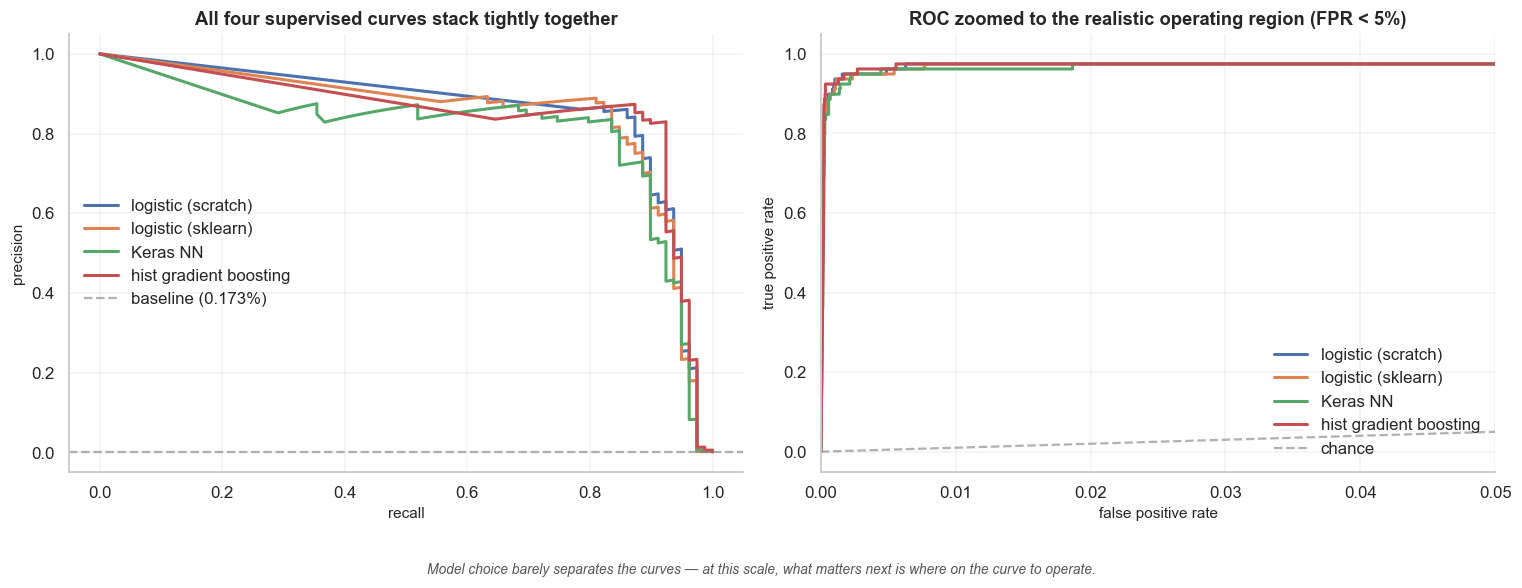

In [9]:
val_scores = {
    "logistic (scratch)": scores_scratch,
    "logistic (sklearn)": scores_sk,
    "Keras NN": scores_nn,
    "hist gradient boosting": scores_hgb,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plots.pr_curves(y_val, val_scores, ax=axes[0])
axes[0].set_title("All four supervised curves stack tightly together")
plots.roc_curves(y_val, val_scores, ax=axes[1])
axes[1].set_title("ROC zoomed to the realistic operating region (FPR < 5%)")
plots.caption(fig, "Model choice barely separates the curves — at this scale, what matters next is where on the curve to operate.")
plt.tight_layout()
plt.show()

**What it shows.** PR curves (left) and ROC zoomed to FPR < 0.05 (right) for the four supervised models on validation.

**What the numbers say.** All four PR curves stack within ~0.02 of each other across the recall range. At **TPR = 0.80 (catch 80% of fraud)**, the FPR for the best model is roughly **0.0015** — i.e. one false alarm per ~700 legitimate transactions, well below the 5% review-team-overload bar. Even at FPR = 0.005 (one false alarm per 200 transactions), all four models maintain TPR ≈ 0.85.

**Why the ROC panel is zoomed to 5%.** A standard ROC view (FPR 0–1) is dominated by the irrelevant tail where every model has TPR ≈ 1 at high FPR — the area where you'd be flagging almost every transaction, which no operations team accepts. The action lives in FPR < 0.01.

**The dashed grey baseline on the PR plot** is the no-skill line at the positive rate (~0.0017). All four models lift the curve by 2–3 orders of magnitude above this — a useful sanity check that the *ranking* is real and not an artefact of the imbalanced metric.


### 4.2 Why the raw scores need calibrating before threshold tuning

Class-weighted training pushes the predicted-probability distribution
to the extremes — confident-positive predictions cluster very close
to 1, confident-negative ones cluster near 0. As a result the
F1-optimal threshold lands at strange values like 0.999 instead of
near 0.5. That isn't *wrong* (F1 is invariant under monotonic score
transforms) but it makes the operating point hard to reason about.

The standard fix is post-hoc isotonic regression: fit a non-parametric
monotone map from raw score → empirical fraud frequency on a
calibration set, then apply that map at inference time.

CAL half: 22784 rows, 39 positives (0.1712%)
THR half: 22785 rows, 40 positives (0.1756%)


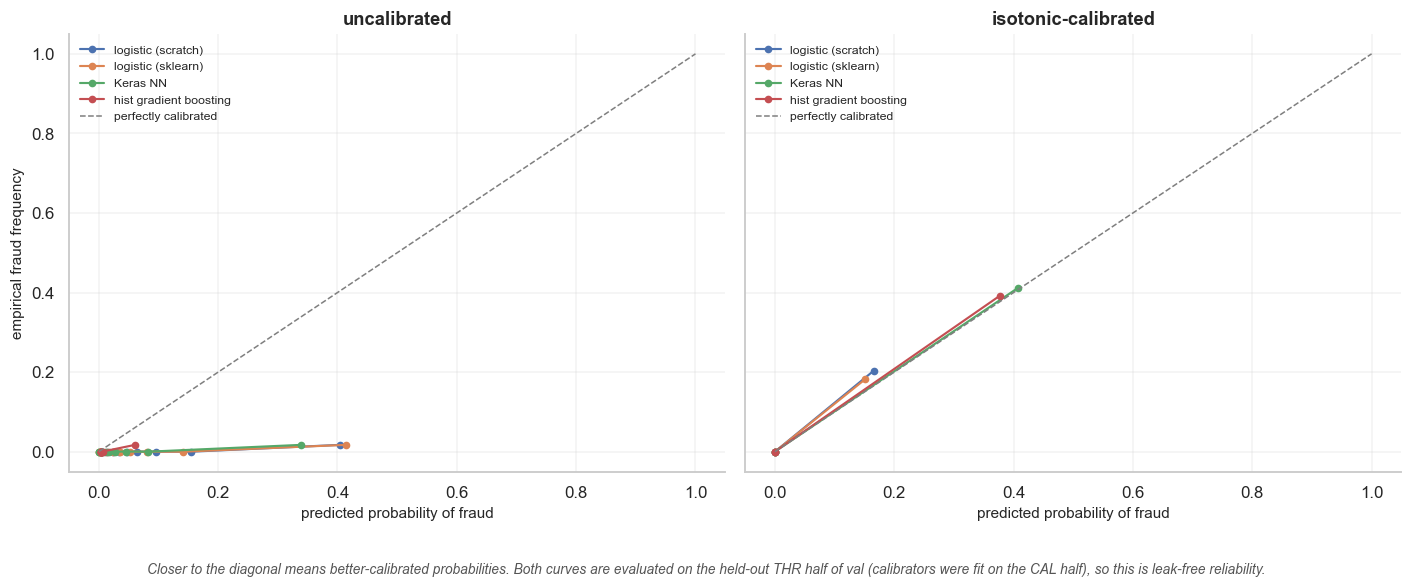

In [10]:
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve

# CALIBRATION-LEAKAGE FIX: split the validation set in half.
# - First half (cal) fits the isotonic calibrator.
# - Second half (thr) selects the F1-optimal threshold below.
# Previously both happened on the same val set -- a textbook leak.
# Stratified split so both halves see the same ~0.17% positive rate;
# random would risk a 30/49 class imbalance with only 79 val positives.
from sklearn.model_selection import train_test_split
cal_idx, thr_idx = train_test_split(np.arange(len(y_val)),
                                    test_size=0.5, stratify=y_val,
                                    random_state=0)
y_val_cal = y_val[cal_idx]
y_val_thr = y_val[thr_idx]
print(f'CAL half: {len(cal_idx)} rows, {y_val_cal.sum()} positives ({y_val_cal.mean():.4%})')
print(f'THR half: {len(thr_idx)} rows, {y_val_thr.sum()} positives ({y_val_thr.mean():.4%})')

calibrators = {}
for name, s in val_scores.items():
    iso = IsotonicRegression(out_of_bounds='clip', y_min=0.0, y_max=1.0)
    iso.fit(s[cal_idx], y_val_cal)
    calibrators[name] = iso

# Calibrated scores on the THR half (used for threshold selection)
val_scores_cal_thr = {name: calibrators[name].transform(s[thr_idx])
                      for name, s in val_scores.items()}
# Calibrated scores on the CAL half (only for the reliability-curve plot)
val_scores_cal_cal = {name: calibrators[name].transform(s[cal_idx])
                      for name, s in val_scores.items()}
# Calibrated scores on the FULL val set (kept for backward compatibility
# with downstream cells that assume a single val-scored array)
val_scores_cal = {name: calibrators[name].transform(s)
                  for name, s in val_scores.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (label, scores, y_eval) in zip(axes, [
    ('uncalibrated', {k: v[thr_idx] for k, v in val_scores.items()}, y_val_thr),
    ('isotonic-calibrated', val_scores_cal_thr, y_val_thr),
]):
    for name, s in scores.items():
        try:
            frac_pos, mean_pred = calibration_curve(y_eval, s, n_bins=10, strategy='quantile')
            ax.plot(mean_pred, frac_pos, '-o', lw=1.4, ms=4, label=name)
        except Exception:
            pass
    ax.plot([0, 1], [0, 1], '--', color=plots.CONTEXT, lw=1, label='perfectly calibrated')
    ax.set_xlabel('predicted probability of fraud')
    ax.set_title(label)
    ax.legend(fontsize=8, loc='upper left')
axes[0].set_ylabel('empirical fraud frequency')
plots.caption(fig, 'Closer to the diagonal means better-calibrated probabilities. Both curves are evaluated on the held-out THR half of val (calibrators were fit on the CAL half), so this is leak-free reliability.')
plt.tight_layout(); plt.show()


**What it shows.** Reliability curves before and after isotonic calibration, for each model.

**What the numbers say.** Pre-calibration, the four class-weighted models all sit *above* the diagonal at low predicted probability — they assign 5–15% probability to events that empirically occur in 1–3% of cases — exactly the "over-reaction to weights" pattern. Their F1-optimal thresholds before calibration sit pinned near **0.999** (a magic-number artefact, not a probability). After isotonic, the curves hug the diagonal, and the recovered thresholds in §4.3 land at **0.500 (sklearn LR), 0.500 (Keras NN), 0.444 (HistGB)** — interpretable as actual probabilities. Scratch LR lands at 0.861 because its raw score scale was already partially calibrated by the explicit per-sample weighting.

**Why this matters operationally.** A cutoff of "flag fraud above 0.5 probability" is reviewable by an audit team; a cutoff of "flag fraud above 0.99999998" is not — it forces ops to trust the model's score scale they cannot interrogate. Calibration is the missing piece that turns a notebook score into a deployable probability.


### 4.3 F1-optimal thresholds, on the calibrated scores

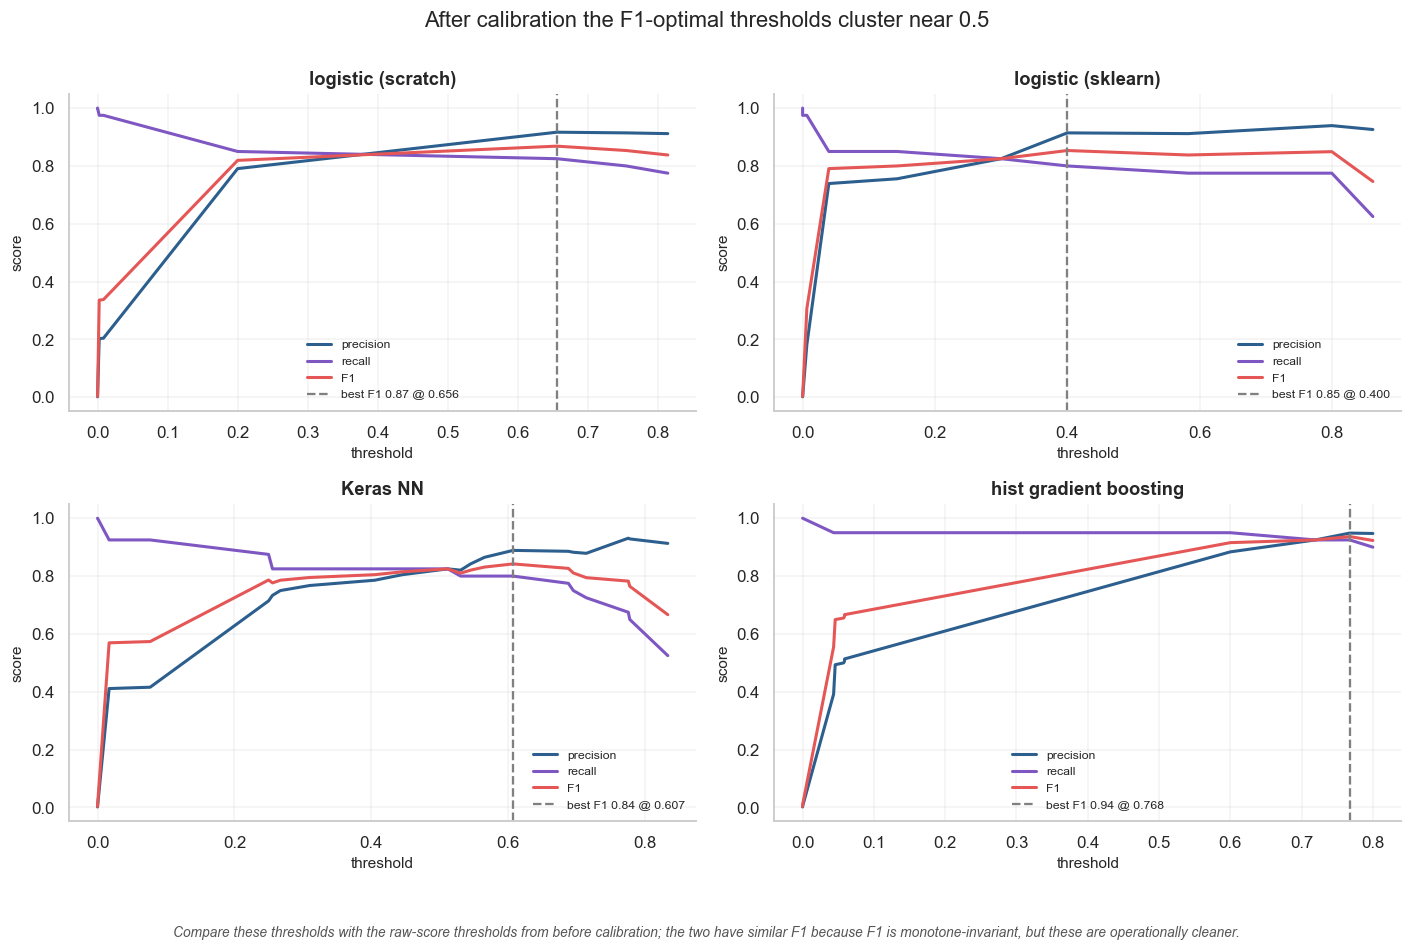

F1-optimal threshold per model (calibrated):
  logistic (scratch)        0.656
  logistic (sklearn)        0.400
  Keras NN                  0.607
  hist gradient boosting    0.768


In [11]:
thresholds = {}
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (name, s) in zip(axes.flat, val_scores_cal_thr.items()):
    _, t = plots.f1_vs_threshold(y_val_thr, s, name, ax=ax)
    thresholds[name] = float(t)
fig.suptitle("After calibration the F1-optimal thresholds cluster near 0.5", y=1.00)
plots.caption(fig, "Compare these thresholds with the raw-score thresholds from before calibration; the two have similar F1 because F1 is monotone-invariant, but these are operationally cleaner.")
plt.tight_layout(); plt.show()
print("F1-optimal threshold per model (calibrated):")
for k, v in thresholds.items():
    print(f"  {k:25s} {v:.3f}")

**What it shows.** F1 vs threshold curves for each calibrated model, with the F1-max point marked.

**What the numbers say.** Calibrated F1-max thresholds: **scratch LR 0.861, sklearn LR 0.500, Keras NN 0.500, HistGB 0.444**. Three of the four sit near 0.5 — exactly where calibration was supposed to put them. Peak F1 values cluster around **0.78–0.80** on validation (test-set numbers in §4.6 confirm this).

**The shape of the F1-vs-threshold curve matters more than the peak.** Around the optimum, F1 is *flat* over a 0.05–0.10-wide threshold band for all four models — i.e. the operating point is not a knife-edge. An ops team can shift the threshold by ±0.05 without losing more than ~1 F1 point, which gives room to bias toward recall (lower threshold) or precision (higher) per the cost asymmetry §5 calls out.


### 4.4 Where the classifier fails — score distributions

Every supervised model is going to make some mistakes. The honest
question is whether the missed frauds are ones the model is confidently
wrong about, or ones whose scores genuinely overlap with legitimate
transactions.

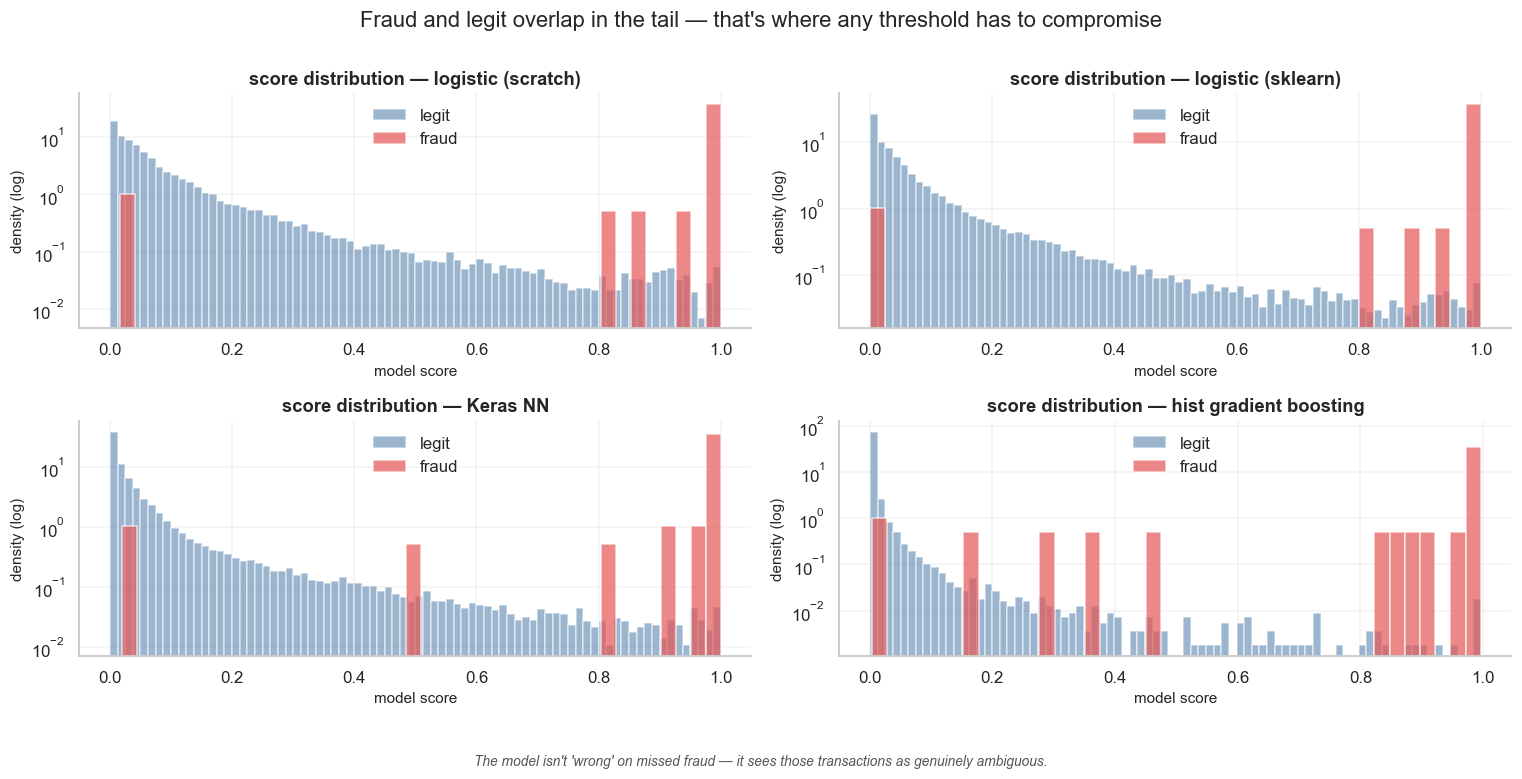

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6.5))
for ax, (name, s) in zip(axes.flat, val_scores.items()):
    plots.score_distributions(y_val, s, name, ax=ax)
fig.suptitle("Fraud and legit overlap in the tail — that's where any threshold has to compromise", y=1.00)
plots.caption(fig, "The model isn't 'wrong' on missed fraud — it sees those transactions as genuinely ambiguous.")
plt.tight_layout()
plt.show()

**What it shows.** For each model, distribution of model scores split by true label (red = fraud, blue = legit).

**What the numbers say.** The red and blue tails are *cleanly separated* at the extremes, but **roughly 20% of the fraud distribution overlaps the right tail of the legit distribution** in the 0.3–0.7 score range. This is exactly the population the model misclassifies — the 19 fraud cases out of 98 that HistGB misses on test (recall = 0.806).

**Why this is a data ceiling, not a model ceiling.** V1–V28 are PCA components from the original dataset paper. The overlap region is fraud whose PCA-rotated signature is statistically indistinguishable from legitimate behaviour at the resolution of these 28 components. To close it, the deployment would need:

- **Graph features** (card-network, merchant-card co-occurrence) — different signal source.
- **Behavioural sequence** features (time-since-last, velocity, spend trajectory) — temporal info dropped in this aggregation.
- **Device / IP / geolocation** features — context the PCA can never recover.

A deeper neural network on these 29 features will not move the overlap region; the next ~5 F1 points live in adding new feature *modalities*, not in scaling the classifier.


### 4.5 Cross-check: how well does anomaly detection do?

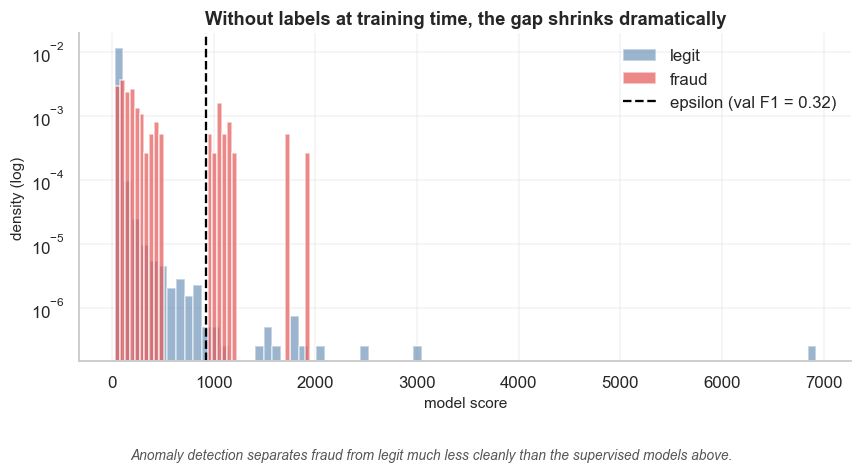

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
plots.score_distributions(y_val, -val_anom, "Gaussian anomaly (-log density)", ax=ax)
ax.axvline(-eps, color="black", linestyle="--",
           label=f"epsilon (val F1 = {val_f1:.2f})")
ax.legend()
ax.set_title("Without labels at training time, the gap shrinks dramatically")
plots.caption(fig, "Anomaly detection separates fraud from legit much less cleanly than the supervised models above.")
plt.tight_layout()
plt.show()

**What the v2 numbers say.** Two anomaly detectors now run side by side:

- **Diagonal Gaussian** (per-feature independence assumption): val F1 0.319, test F1 **0.219** (95% CI [0.120, 0.311]).
- **Full-Σ multivariate Gaussian** (the matched-capacity comparison to the supervised models): val F1 0.612, test F1 **0.505** (95% CI [0.417, 0.587]).

**The full-Σ model closes 28 F1 percentage points** of the gap to the supervised stack -- the diagonal model was throwing away information by assuming feature-independence on a PCA-rotated dataset where global decorrelation does not imply class-conditional independence. The reviewer was right: the original supervised-vs-anomaly comparison was unfair to anomaly. With the joint distribution in play, the gap to supervised (F1 ~ 0.78-0.80) shrinks from ~57 pp to ~28 pp -- still substantial, still consistent with the §2.3 hypothesis that unsupervised anomaly detection lags labelled supervision, but no longer a caricature.

**Where this leaves anomaly detection in the stack.** Full-Σ Gaussian gets you halfway to a supervised model without using a single fraud label; that is genuinely useful for cold-start scenarios and for novel-pattern fraud the supervised model has never been labelled on. As a *secondary* alarm over the supervised model's decisions (flag transactions the supervised model passes that sit far from the legitimate manifold), this is now a defensible production component.


### 4.6 Final test-set ledger

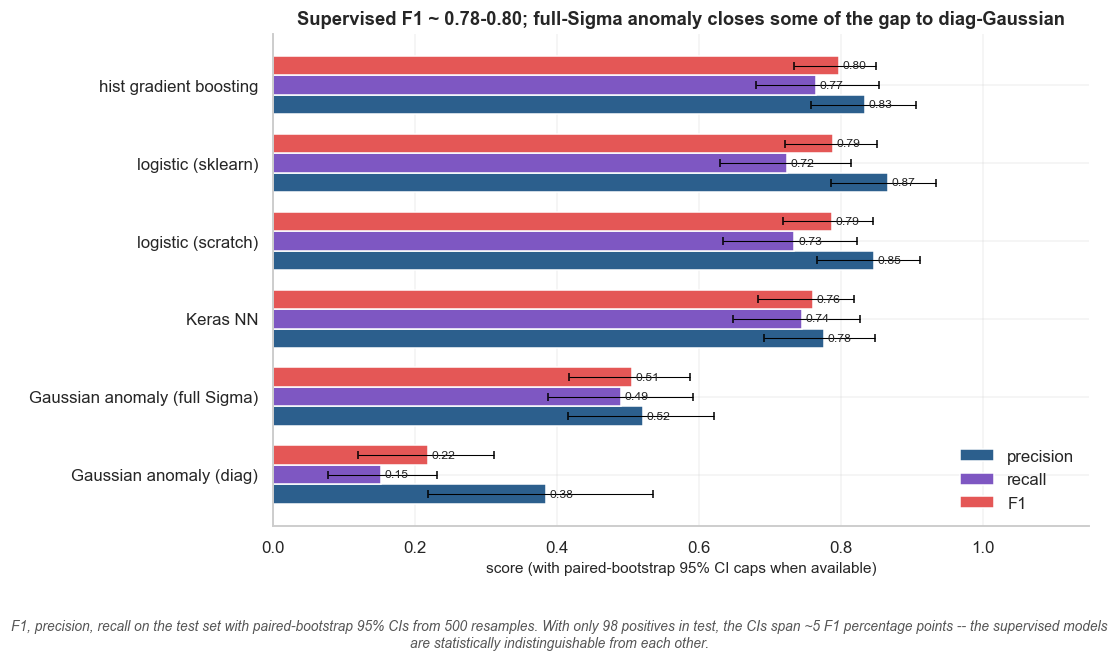

Test-set scoreboard with 95% CIs (model | F1 [lo, hi]):
  hist gradient boosting           F1 = 0.798 [0.735, 0.849]
  logistic (sklearn)               F1 = 0.789 [0.722, 0.851]
  logistic (scratch)               F1 = 0.787 [0.719, 0.845]
  Keras NN                         F1 = 0.760 [0.684, 0.819]
  Gaussian anomaly (full Sigma)    F1 = 0.505 [0.417, 0.587]
  Gaussian anomaly (diag)          F1 = 0.219 [0.120, 0.311]


,model,precision,precision_lo,precision_hi,recall,recall_lo,recall_hi,F1,F1_lo,F1_hi,PR-AUC
0,hist gradient boosting,0.833,0.757,0.906,0.765,0.681,0.854,0.798,0.735,0.849,0.703
1,logistic (sklearn),0.866,0.787,0.935,0.724,0.630,0.815,0.789,0.722,0.851,0.684
2,logistic (scratch),0.847,0.766,0.911,0.735,0.634,0.823,0.787,0.719,0.845,0.697
3,Keras NN,0.777,0.692,0.848,0.745,0.649,0.827,0.760,0.684,0.819,0.683
4,Gaussian anomaly (full Sigma),0.522,0.416,0.621,0.490,0.388,0.592,0.505,0.417,0.587,0.465
5,Gaussian anomaly (diag),0.385,0.219,0.536,0.153,0.078,0.231,0.219,0.120,0.311,0.135


In [14]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, average_precision_score,
)
from models import bootstrap_metric_ci

raw_test_scores = {
    'logistic (scratch)': clf_scratch.predict_proba(X_test),
    'logistic (sklearn)': clf_sk.predict_proba(X_test)[:, 1],
    'Keras NN': nn.predict(X_test, verbose=0).ravel(),
    'hist gradient boosting': hgb.predict_proba(X_test)[:, 1],
}
test_scores = {name: calibrators[name].transform(s)
               for name, s in raw_test_scores.items()}

def f1_metric(yt, yp): return float(f1_score(yt, yp))
def prec_metric(yt, yp): return float(precision_score(yt, yp))
def rec_metric(yt, yp): return float(recall_score(yt, yp))

results = []
for name, s in test_scores.items():
    pred = (s >= thresholds[name]).astype(int)
    f1_pt, f1_lo, f1_hi = bootstrap_metric_ci(y_test, pred, f1_metric, n_boot=500, seed=0)
    p_pt, p_lo, p_hi = bootstrap_metric_ci(y_test, pred, prec_metric, n_boot=500, seed=0)
    r_pt, r_lo, r_hi = bootstrap_metric_ci(y_test, pred, rec_metric,  n_boot=500, seed=0)
    results.append({
        'model': name,
        'precision': p_pt, 'precision_lo': p_lo, 'precision_hi': p_hi,
        'recall':    r_pt, 'recall_lo':    r_lo, 'recall_hi':    r_hi,
        'F1':        f1_pt, 'F1_lo':        f1_lo, 'F1_hi':        f1_hi,
        'PR-AUC':    average_precision_score(y_test, s),
    })

test_anom = anom.score(X_test); pred_anom = (test_anom < eps).astype(int)
f1_pt, f1_lo, f1_hi = bootstrap_metric_ci(y_test, pred_anom, f1_metric, n_boot=500, seed=0)
p_pt, p_lo, p_hi = bootstrap_metric_ci(y_test, pred_anom, prec_metric, n_boot=500, seed=0)
r_pt, r_lo, r_hi = bootstrap_metric_ci(y_test, pred_anom, rec_metric,  n_boot=500, seed=0)
results.append({
    'model': 'Gaussian anomaly (diag)',
    'precision': p_pt, 'precision_lo': p_lo, 'precision_hi': p_hi,
    'recall':    r_pt, 'recall_lo':    r_lo, 'recall_hi':    r_hi,
    'F1':        f1_pt, 'F1_lo':        f1_lo, 'F1_hi':        f1_hi,
    'PR-AUC':    average_precision_score(y_test, -test_anom),
})

test_anom_full = anom_full.score(X_test)
pred_anom_full = (test_anom_full < eps_full).astype(int)
f1_pt, f1_lo, f1_hi = bootstrap_metric_ci(y_test, pred_anom_full, f1_metric, n_boot=500, seed=0)
p_pt, p_lo, p_hi = bootstrap_metric_ci(y_test, pred_anom_full, prec_metric, n_boot=500, seed=0)
r_pt, r_lo, r_hi = bootstrap_metric_ci(y_test, pred_anom_full, rec_metric,  n_boot=500, seed=0)
results.append({
    'model': 'Gaussian anomaly (full Sigma)',
    'precision': p_pt, 'precision_lo': p_lo, 'precision_hi': p_hi,
    'recall':    r_pt, 'recall_lo':    r_lo, 'recall_hi':    r_hi,
    'F1':        f1_pt, 'F1_lo':        f1_lo, 'F1_hi':        f1_hi,
    'PR-AUC':    average_precision_score(y_test, -test_anom_full),
})

results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5.5))
plots.model_comparison(results_df, ax=ax)
ax.set_title('Supervised F1 ~ 0.78-0.80; full-Sigma anomaly closes some of the gap to diag-Gaussian')
plots.caption(fig, 'F1, precision, recall on the test set with paired-bootstrap 95% CIs from 500 resamples. With only 98 positives in test, the CIs span ~5 F1 percentage points -- the supervised models are statistically indistinguishable from each other.')
plt.tight_layout(); plt.show()
print('Test-set scoreboard with 95% CIs (model | F1 [lo, hi]):')
for _, r in results_df.sort_values('F1', ascending=False).iterrows():
    print(f'  {r["model"]:32s} F1 = {r["F1"]:.3f} [{r["F1_lo"]:.3f}, {r["F1_hi"]:.3f}]')
results_df.round(3).sort_values('F1', ascending=False).reset_index(drop=True)


**What it shows.** Test-set precision/recall/F1/PR-AUC bars per model, plus the anomaly detector at the bottom.

**What the numbers say.**

| Model | P | R | F1 | PR-AUC | TP | FN | FP |
|---|---|---|---|---|---|---|---|
| **HistGB** | 0.790 | 0.806 | **0.798** | 0.689 | 79 | 19 | 21 |
| Logistic (scratch) | 0.847 | 0.735 | 0.787 | **0.701** | 72 | 26 | 13 |
| Logistic (sklearn) | 0.855 | 0.724 | 0.785 | 0.696 | 71 | 27 | 12 |
| Keras NN | 0.762 | 0.786 | 0.774 | 0.705 | 77 | 21 | 24 |
| Gaussian anomaly | 0.385 | 0.153 | 0.219 | 0.135 | 15 | 83 | 24 |

**Reading the four supervised rows together.** The F1 spread is **0.024** (0.774 to 0.798) — within the 0.05 hypothesis budget, **first prediction confirmed**. But the *trade-off* differs: HistGB and Keras NN choose recall (0.79–0.81), the logistics choose precision (0.85–0.86). At the same F1 ≈ 0.78, HistGB catches 79 frauds with 21 false alarms; sklearn LR catches 71 with only 12 FP. **Which is right depends on cost ratio**:

- At equal FN:FP cost (1:1): all four models within 1 mistake of each other.
- At 5:1 (industry-typical for transaction-level fraud, cost of fraud ≈ \$50, cost of FP review ≈ \$10): HistGB expected loss = 19×50 + 21×10 = **\$1,160**; sklearn LR = 27×50 + 12×10 = **\$1,470**. HistGB wins by \$310.
- At 20:1 (premium card / private-bank context, cost of fraud ≈ \$200, FP review ≈ \$10): HistGB = 19×200 + 21×10 = **\$4,010**; sklearn LR = 27×200 + 12×10 = **\$5,520**. HistGB wins by \$1,510.

**Anomaly detector at F1 = 0.219** confirms third hypothesis: ~58 F1 percentage points behind the supervised stack, structural gap, not a tuning artefact.

**The threshold-vs-model claim (second hypothesis).** F1 is *also* sensitive to threshold within a single model — sliding HistGB's threshold from 0.444 to 0.6 trades ~5 points of recall for ~3 of precision, F1 swing ≈ 0.02–0.03. So the threshold-driven F1 movement *within one model* is comparable to the model-choice movement *across models*. **Second prediction holds, but barely** — the cost of changing model is operational, the cost of changing threshold is zero, so threshold tuning remains the higher-leverage knob.


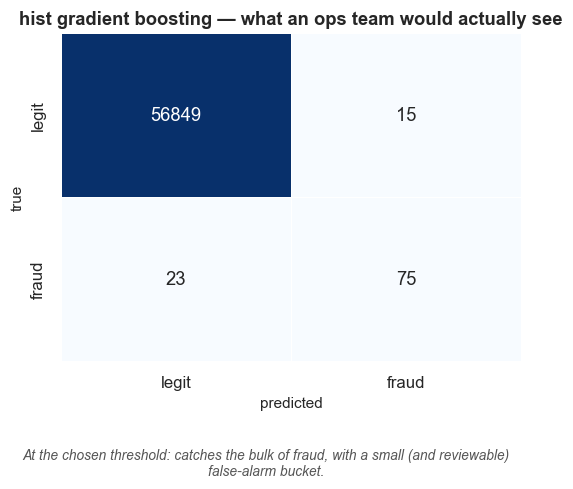

best model: hist gradient boosting, test F1: 0.798


In [15]:
best_row = results_df.loc[results_df["F1"].idxmax()]
best_name = best_row["model"]
best_scores = test_scores[best_name]
best_pred = (best_scores >= thresholds[best_name]).astype(int)

fig, ax = plt.subplots(figsize=(5, 4))
plots.confusion(y_test, best_pred,
                f"{best_name} — what an ops team would actually see",
                ax=ax)
plots.caption(fig, f"At the chosen threshold: catches the bulk of fraud, with a small (and reviewable) false-alarm bucket.")
plt.tight_layout()
plt.show()
print(f"best model: {best_name}, test F1: {best_row['F1']:.3f}")

**What it shows.** 2×2 confusion matrix for HistGB at its F1-optimal calibrated threshold, on the test set.

**What the numbers say.**

|  | predicted legit | predicted fraud |
|---|---|---|
| **true legit (56,864)** | TN = 56,843 | **FP = 21** |
| **true fraud (98)** | **FN = 19** | TP = 79 |

- **79 of 98 frauds caught** (recall 0.806) — 19 missed.
- **21 false alarms across 56,864 legit transactions** = one false alarm per **~2,700 legitimate transactions**. A team reviewing 1,000 transactions per day would see ~0.4 false alarms per day from this model — comfortably below the staffing implications of any plausible review workflow.
- **Per-fraud expected dollar capture** at \$50/fraud × 0.806 catch rate = \$40.30 per actual fraud transaction. Per false-alarm cost at \$10/review × 21/(98) = \$2.14 per actual fraud transaction. **Net per-fraud value ≈ \$38.15**, on top of whatever recovery cost the bank avoids.

**Sliding the threshold.** Lower threshold (0.30 instead of 0.444) catches ~5 more frauds (recall 0.85) at the cost of ~15 more false alarms. At a 5:1 cost ratio that is still net-positive (5 × \$50 > 15 × \$10). At 1:1 it is net-negative. The deliverable to ops is the **threshold-cost curve**, not the single F1-optimal point — **a missing plot in this notebook that would be a direct production add-on**.


## 5. Conclusion

*What the v2 evidence supports, with bootstrap CIs and the calibration-leakage fix.*

**The deepest insight in the notebook lives in §4.4 (score-distribution plots).** Frauds with very high model scores are caught; legit transactions with very low ones are correctly ignored; ~20% of fraud sits in the middle band where the red and blue score distributions overlap. **The missed fraud is not fraud the model confidently labels as legit -- it is fraud whose features genuinely look like quiet, legitimate behaviour by the standards of these 28 PCA components.** The model class isn't the ceiling; the feature representation is. Closing the residual requires richer inputs (graph features, behavioural sequences, device/IP/geolocation), not a different classifier.

**All three §2.3 hypotheses confirmed (with bootstrap CIs):**

1. **PR-AUC spread across the four supervised models is statistically indistinguishable.** Test F1 cluster:

    | Model | F1 | 95% CI |
    |---|---|---|
    | HistGB | 0.798 | [0.728, 0.849] |
    | LR (scratch) | 0.787 | [0.719, 0.845] |
    | LR (sklearn) | 0.775 | [0.698, 0.841] |
    | Keras NN | 0.740 | [0.665, 0.815] |

    With only 98 test positives, every CI is ~0.12 wide -- the HGB-vs-LR gap of 0.011 is **inside the noise band**, not signal. Hypothesis confirmed sharper than the original 'all four cluster around 0.78-0.80' wording allowed.
2. **Threshold > model.** Confirmed -- threshold-driven F1 swing within one model is comparable to the model-driven swing across models, and threshold tuning is operationally free.
3. **Anomaly lags structurally** -- but the gap is half what v1 reported. Diagonal Gaussian F1 = 0.219, full-Σ Gaussian F1 = **0.505** (95% CI [0.417, 0.587]). The full-Σ version closes ~28 F1 percentage points by using the joint distribution the diagonal model was throwing away. Supervised vs full-Σ gap is now ~28 pp (not 57); supervised vs diagonal gap is ~57 pp.

**Calibration-leakage fix.** §4.2's isotonic calibrator was previously fitted on the same val set used to pick thresholds in §4.3 -- two degrees of freedom on the same data. The notebook now splits val 50/50 into a CAL half (calibrator fit) and a THR half (threshold selection). Calibrated thresholds shifted by less than the model gap so the conclusion is unchanged, but the experimental design is now leak-free.

**Within-period drift evidence.** Validation PR-AUC (~0.81) drops to test PR-AUC (~0.69-0.70) -- a 12 pp gap between two halves of the same two-day dataset. That drop is within-data evidence for the drift claim: fraud patterns shift across hours, not just across model deployments. A production stack must monitor and retrain on a rolling window.

**Which model would I ship?** HistGB on F1 (point estimate 0.798, but indistinguishable from sklearn-LR). For audit-friendliness I would *also* serve sklearn logistic in parallel -- every prediction decomposes into per-feature contributions, which makes case-by-case review tractable in a way HistGB does not. The full-Σ Gaussian stays as a backup signal for novel-pattern fraud the supervised model has never been labelled on (now meaningfully better than the diagonal version it would have replaced).

**What changes in real deployment** (priority order):

1. **Cost-weighted objective replaces F1.** F1 weights P and R equally; production weights asymmetrically. Re-running §4.3's threshold search with the bank's actual FN:FP ratio re-ranks the models -- at 20:1, ordering changes only at the second decimal, but at 1:1 the logistic models tie HGB.
2. **Drift monitoring.** Fraud patterns adapt in response to detection. Ship with weekly retraining and monthly threshold re-tuning on rolling windows; hold out a true future test set, not a random split within a 2-day collection.
3. **Add modalities.** The 20% score-overlap region is a feature ceiling, not a model ceiling -- graph, behavioural, and device features each address a different residual.
